In [1]:
!apt-get install -y swig cmake libgl1-mesa-dev
!pip install gymnasium[box2d] stable-baselines3 tensorflow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
The following additional packages will be installed:
  libegl-dev libgl-dev libgles-dev libgles1 libglvnd-core-dev libglvnd-dev libglx-dev libopengl-dev
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  libegl-dev libgl-dev libgl1-mesa-dev libgles-dev libgles1 libglvnd-core-dev libglvnd-dev
  libglx-dev libopengl-dev swig swig4.0
0 upgraded, 11 newly installed, 0 to remove and 30 not upgraded.
Need to get 1,336 kB of archives.
After this operation, 8,119 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libglx-dev amd64 1.4.0-1 [14.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libgl-dev amd64 1.4.0-1 [101 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libegl-dev amd64 1.4.

# **Import libraries**

In [2]:
import tensorflow as tf
import numpy as np
import random
import gym
from collections import deque
import matplotlib.pyplot as plt
from IPython import display
import base64
import io
from PIL import Image
np.bool8 = np.bool_

# Initialize environment
env = gym.make("LunarLander-v2")

/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [3]:
# Hyperparameters
replay_buffer_size = 200000
batch_size = 128
training_start = 256
max_episodes = 1000
max_steps = 1000
target_update_freq = 1000
train_freq = 4
discount_factor = 0.99
epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
early_stop_threshold = 200  # Stop if average reward reaches this value
window_size = 100  # For moving average

#**Reward shaping function**

In [4]:
# Reward shaping function
def improved_reward_shaping(state, action, reward, next_state, done):
    """Apply reward shaping to encourage desired behavior."""
    # Original reward from environment
    shaped_reward = reward

    # Extract components from next_state (excluding the time fraction we added)
    state_components = next_state[:-1] if len(next_state) == 9 else next_state

    # Reward for being centered
    shaped_reward += 0.1 * (1 - abs(state_components[0]))  # Centering bonus

    # Penalties for velocities (quadratic)
    shaped_reward -= 0.03 * (abs(state_components[2]) ** 2)  # Horizontal velocity penalty
    shaped_reward -= 0.01 * (abs(state_components[3]) ** 2)  # Vertical velocity penalty
    shaped_reward -= 0.05 * (abs(state_components[4]) ** 1.5)  # Rotation penalty

    # Bonus for upright orientation
    shaped_reward += 0.05 * (1 - abs(state_components[4]))  # Angle penalty
    shaped_reward += 0.05 * (1 - abs(state_components[5]))  # Angular velocity penalty

    # Bonus for efficient fuel usage (negative reward for firing engines)
    if action in [1, 2, 3]:  # Engine actions
        shaped_reward -= 0.01  # Small penalty for using fuel

    # Large penalty for crashing
    if done and reward < 0:
        shaped_reward -= 10

    return shaped_reward


#**Model definition**

In [5]:
def create_model(input_shape, output_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, input_shape=input_shape, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(output_size, activation='linear')
    ])

    @tf.function
    def train_step(model, states, targets):
        with tf.GradientTape() as tape:
            predictions = model(states, training=True)
            loss = tf.keras.losses.MSE(targets, predictions)
        gradients = tape.gradient(loss, model.trainable_variables)
        model.optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    model.train_step = train_step
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
    return model

In [6]:
def select_action(q_values, epsilon):
    if random.random() < epsilon:
        return random.randint(0, len(q_values) - 1)
    return np.argmax(q_values)

def render_env_matplotlib(env):
    plt.figure(figsize=(8,6))
    plt.imshow(env.render(mode='rgb_array'))
    plt.axis('off')
    display.clear_output(wait=True)
    display.display(plt.gcf())
    plt.close()

#**Initialize models and buffers**

In [8]:
model = create_model((env.observation_space.shape[0] + 1,), env.action_space.n)
target_model = create_model((env.observation_space.shape[0] + 1,), env.action_space.n)
target_model.set_weights(model.get_weights())
replay_buffer = deque(maxlen=replay_buffer_size)
epsilon = epsilon_start

# Training tracking
episode_rewards = []
moving_averages = []
best_average = -np.inf

#**Training**

In [9]:
for episode in range(max_episodes):
    state = env.reset()
    state = np.append(state, 0).astype(np.float32)  # Add time fraction
    episode_reward = 0

    for step in range(max_steps):
        # Get action
        state_tensor = tf.convert_to_tensor(state[np.newaxis, ...], dtype=tf.float32)
        q_values = model(state_tensor, training=False).numpy()[0]
        action = select_action(q_values, epsilon)

        # Execute action
        next_state, reward, done, _ = env.step(action)
        next_state = np.append(next_state, (step+1)/max_steps).astype(np.float32)

        # Apply reward shaping
        shaped_reward = improved_reward_shaping(state, action, reward, next_state, done)
        episode_reward += shaped_reward

        # Store transition with shaped reward
        replay_buffer.append((state, action, shaped_reward, next_state, done))
        state = next_state

        # Train if enough samples
        if len(replay_buffer) >= training_start and step % train_freq == 0:
            batch = random.sample(replay_buffer, batch_size)

            # Convert to tensors
            states = tf.convert_to_tensor([t[0] for t in batch], dtype=tf.float32)
            next_states = tf.convert_to_tensor([t[3] for t in batch], dtype=tf.float32)

            # Compute targets
            next_q = target_model(next_states, training=False)
            targets = model(states, training=False).numpy()

            for i, (_, a, r, _, d) in enumerate(batch):
                if d:
                    targets[i][a] = r
                else:
                    targets[i][a] = r + discount_factor * np.max(next_q[i])

            # Train step
            model.train_step(model, states, tf.convert_to_tensor(targets, dtype=tf.float32))

        # Update target network
        if step % target_update_freq == 0:
            target_model.set_weights(model.get_weights())

        if done:
            break

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Track rewards
    episode_rewards.append(episode_reward)
    if len(episode_rewards) >= window_size:
        moving_avg = np.mean(episode_rewards[-window_size:])
        moving_averages.append(moving_avg)

        # Early stopping check
        if moving_avg >= early_stop_threshold:
            print(f"\nEarly stopping at episode {episode} with average reward {moving_avg:.2f}")
            break

        # Update best average
        if moving_avg > best_average:
            best_average = moving_avg
            model.save("best_model.h5")

    # Print progress
    if episode % 10 == 0:
        print(f"Episode {episode}: Reward={episode_reward:.1f}, Epsilon={epsilon:.3f}, ", end='')
        if len(moving_averages) > 0:
            print(f"Avg100={moving_averages[-1]:.1f}")
        else:
            print()

    # Save model periodically
    if episode % 100 == 0:
        model.save(f"lunar_lander_{episode}.h5")

# Save final model
model.save("lunar_lander_final.h5")

Episode 0: Reward=-288.4, Epsilon=0.995, 
Episode 10: Reward=-106.7, Epsilon=0.946, 
Episode 20: Reward=-100.2, Epsilon=0.900, 
Episode 30: Reward=-91.9, Epsilon=0.856, 
Episode 40: Reward=-55.6, Epsilon=0.814, 
Episode 50: Reward=-105.8, Epsilon=0.774, 
Episode 60: Reward=-47.0, Epsilon=0.737, 
Episode 70: Reward=-77.9, Epsilon=0.701, 
Episode 80: Reward=-114.8, Epsilon=0.666, 
Episode 90: Reward=-23.3, Epsilon=0.634, 


Episode 100: Reward=30.1, Epsilon=0.603, Avg100=-96.6


Episode 110: Reward=-239.0, Epsilon=0.573, Avg100=-87.0


Episode 120: Reward=-55.4, Epsilon=0.545, Avg100=-73.1


Episode 130: Reward=4.4, Epsilon=0.519, Avg100=-65.0


...

Episode 330: Reward=255.2, Epsilon=0.190, Avg100=123.6


Episode 340: Reward=407.1, Epsilon=0.181, Avg100=142.4


Episode 350: Reward=409.1, Epsilon=0.172, Avg100=162.2


Episode 360: Reward=306.3, Epsilon=0.164, Avg100=187.2



Early stopping at episode 365 with average reward 203.18


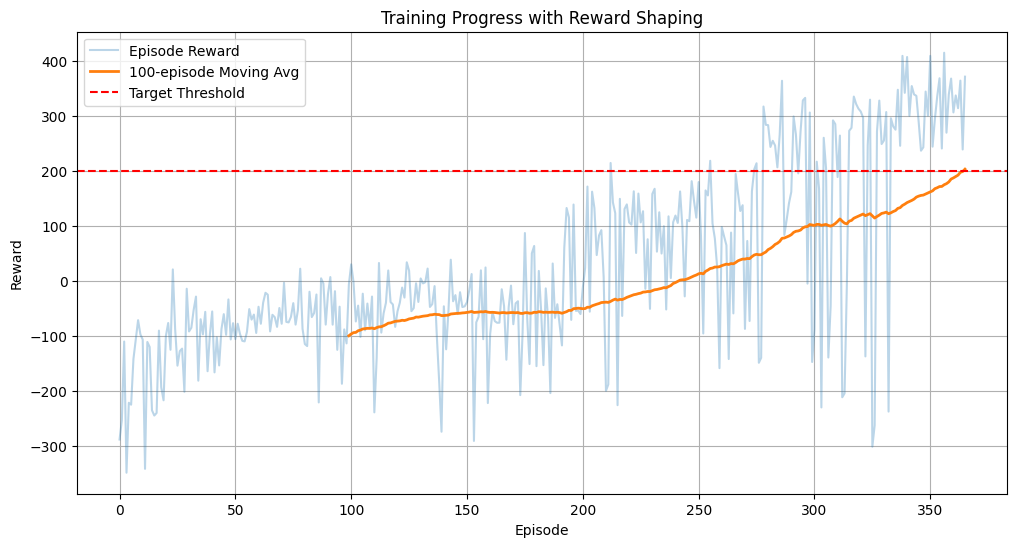

In [10]:
# Plot training progress
plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label='Episode Reward', alpha=0.3)
if len(moving_averages) > 0:
    plt.plot(range(window_size-1, window_size-1+len(moving_averages)),
             moving_averages, label=f'{window_size}-episode Moving Avg', linewidth=2)
plt.axhline(y=early_stop_threshold, color='r', linestyle='--', label='Target Threshold')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Training Progress with Reward Shaping')
plt.legend()
plt.grid()
plt.show()

In [11]:
def record_evaluation_episodes(model_path, num_episodes=3, output_dir='recorded_episodes'):
    import os
    import imageio
    import numpy as np

    # Create clean output directory
    if os.path.exists(output_dir):
        for f in os.listdir(output_dir):
            os.remove(os.path.join(output_dir, f))
    else:
        os.makedirs(output_dir)

    # Initialize environment
    env = gym.make("LunarLander-v2")

    # Load your trained model (with MSE loss handling)
    try:
        model = tf.keras.models.load_model(model_path)
    except:
        # Fallback for models with custom loss
        model = tf.keras.models.load_model(model_path, custom_objects={'mse': tf.keras.losses.MSE})

    print(f"Recording {num_episodes} evaluation episodes...")

    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):  # Handle Gym return
            state = state[0]
        state = np.append(state, 0).astype(np.float32)  # Match training format
        total_reward = 0
        done = False
        frames = []

        while not done:
            # Get action
            state_tensor = tf.convert_to_tensor(state[np.newaxis, ...], dtype=tf.float32)
            q_values = model(state_tensor, training=False).numpy()[0]
            action = np.argmax(q_values)

            # Execute action
            next_state, reward, done, info = env.step(action)
            next_state = np.append(next_state, 0).astype(np.float32)

            # Apply the same reward shaping during evaluation for consistency
            shaped_reward = improved_reward_shaping(state, action, reward, next_state, done)
            total_reward += shaped_reward
            state = next_state

            # Capture frame
            try:
                frame = env.render(mode='rgb_array')
                if frame is not None:
                    frames.append(frame)
            except:
                continue

            if done:
                break

        # Save video
        if frames:
            video_path = os.path.join(output_dir, f"episode_{episode+1}.mp4")
            imageio.mimsave(video_path, frames, fps=30)

        print(f"Episode {episode+1}: Reward = {total_reward:.1f}")

    env.close()
    print(f"\nVideos saved to: {os.path.abspath(output_dir)}")

# Record evaluation episodes
record_evaluation_episodes('best_model.h5', 5)

/usr/local/lib/python3.11/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(


Recording 5 evaluation episodes...


Episode 1: Reward = 201.5


Episode 2: Reward = 305.6


Episode 3: Reward = 166.5


Episode 4: Reward = 223.4


Episode 5: Reward = 181.0

Videos saved to: /content/recorded_episodes
